# Báo Cáo Giữ Kỳ: Phân Tích Sự Hài Lòng Khách Hàng - Thẻ Nhớ SanDisk Ultra MicroSD

**Môn học:** Trực quan hóa dữ liệu (Data Visualization)

**Mục tiêu:** Áp dụng các kỹ thuật trực quan hóa dữ liệu để khám phá và phân tích tập dữ liệu đánh giá thực tế của khách hàng.

---

### 1. Xác định Vấn Đề (Problem Definition)

**Câu hỏi nghiên cứu chính:**
"Sự hài lòng của khách hàng đối với sản phẩm thẻ nhớ SanDisk Ultra MicroSD được thể hiện như thế nào qua các đánh giá? Có thể nhận thấy những xu hướng, vấn đề nổi bật nào về chất lượng sản phẩm, tốc độ, độ tin cậy qua thời gian và qua nội dung bình luận của họ hay không?"

**Các câu hỏi phụ (Sub-questions):**
1. Điểm đánh giá trung bình (overall rating) là bao nhiêu và phân bố của nó ra sao?
2. Có mối liên hệ nào giữa thời gian đánh giá và điểm số hay số lượng bình luận hữu ích không?
3. Những chủ đề chính (tích cực và tiêu cực) mà người dùng thường xuyên đề cập trong bình luận của họ là gì?
4. Các vấn đề về "dung lượng thực tế" (capacity), "tốc độ" (speed) hoặc "độ bền" (durability) có được phản ánh rõ trong dữ liệu không?

---

### 2. Chuẩn bị Dữ liệu (Data Processing)

Sử dụng các thư viện cơ bản: `numpy`, `pandas`, `matplotlib`, và `seaborn`.

In [48]:
# Import các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

# Thiết lập phong cách (style) cho biểu đồ
plt.style.use('ggplot')
sns.set_palette("muted")
plt.rcParams.update({'font.size': 12})

# Đọc dữ liệu từ file CSV
# (Giả định file amazon_review.csv nằm cùng thư mục)
df = pd.read_csv('amazon_review.csv')

# Hiển thị thông tin cơ bản
print("Kích thước tập dữ liệu:", df.shape)
df.head()

Kích thước tập dữ liệu: (4915, 12)


,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime,day_diff,helpful_yes,total_vote
0,A3SBTW3WS4IQSN,B007WTAJTO,NaN,"[0, 0]",No issues.,4.0,Four Stars,1406073600,2014-07-23,138,0,0
1,A18K1ODH1I2MVB,B007WTAJTO,0mie,"[0, 0]","Purchased this for my device, it worked as adv...",5.0,MOAR SPACE!!!,1382659200,2013-10-25,409,0,0
2,A2FII3I2MBMUIA,B007WTAJTO,1K3,"[0, 0]",it works as expected. I should have sprung for...,4.0,nothing to really say....,1356220800,2012-12-23,715,0,0
3,A3H99DFEG68SR,B007WTAJTO,1m2,"[0, 0]",This think has worked out great.Had a diff. br...,5.0,Great buy at this price!!! *** UPDATE,1384992000,2013-11-21,382,0,0
4,A375ZM4U047O79,B007WTAJTO,2&amp;1/2Men,"[0, 0]","Bought it with Retail Packaging, arrived legit...",5.0,best deal around,1373673600,2013-07-13,513,0,0


#### Làm sạch dữ liệu (Data Cleaning)
Chuyển đổi cột thời gian và trích xuất các thông tin số từ cột `helpful`.

In [49]:
# Chuyển cột reviewTime sang định dạng datetime
df['reviewDate'] = pd.to_datetime(df['reviewTime'])

# Tạo cột năm (Year) và tháng-năm (YearMonth) để phân tích theo thời gian
df['Year'] = df['reviewDate'].dt.year
df['YearMonth'] = df['reviewDate'].dt.to_period('M')

# Làm sạch dữ liệu văn bản: đưa về chữ thường và điền các giá trị rỗng
df['reviewText'] = df['reviewText'].fillna('').str.lower()
df['summary'] = df['summary'].fillna('').str.lower()

# Đảm bảo cột overall là số liệu numeric
df['overall'] = pd.to_numeric(df['overall'], errors='coerce').dropna()

print("Dữ liệu đã sẵn sàng cho phân tích!")

Dữ liệu đã sẵn sàng cho phân tích!


---
### 3. Trực Quan Hóa (Visualizations)

#### Câu hỏi phụ 1: Điểm đánh giá trung bình là bao nhiêu và phân bố ra sao?

Điểm đánh giá trung bình: 4.59 / 5.0


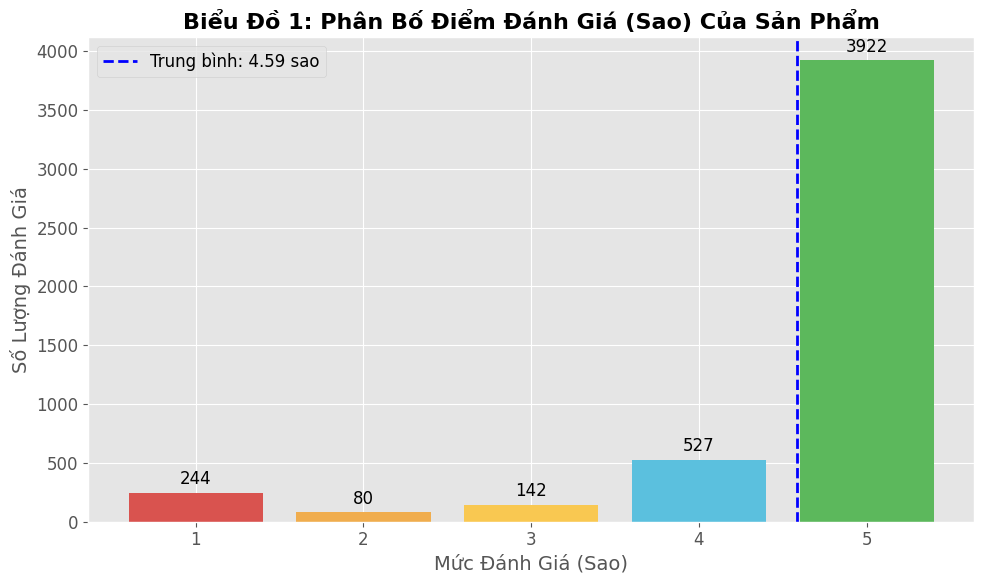

In [50]:
# Tính điểm đánh giá trung bình
avg_rating = df['overall'].mean()
print(f"Điểm đánh giá trung bình: {avg_rating:.2f} / 5.0")

# Tính số lượng đánh giá cho mỗi mức sao
rating_counts = df['overall'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
# Vẽ biểu đồ cột hiển thị phân bố sao
bars = plt.bar(rating_counts.index, rating_counts.values, color=['#d9534f', '#f0ad4e', '#f9c851', '#5bc0de', '#5cb85c'])

plt.title('Biểu Đồ 1: Phân Bố Điểm Đánh Giá (Sao) Của Sản Phẩm', fontsize=16, fontweight='bold')
plt.xlabel('Mức Đánh Giá (Sao)', fontsize=14)
plt.ylabel('Số Lượng Đánh Giá', fontsize=14)
plt.xticks([1, 2, 3, 4, 5])

# Thêm nhãn giá trị trên mỗi cột
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + (max(rating_counts.values)*0.01),
            int(yval), ha='center', va='bottom', fontsize=12)

# Thêm đường kẻ ngang thể hiện trung bình cộng
plt.axvline(x=avg_rating, color='blue', linestyle='--', linewidth=2, label=f'Trung bình: {avg_rating:.2f} sao')
plt.legend()

plt.tight_layout()
plt.show()

**Nhận xét:** Đa số người dùng cực kỳ hài lòng với sản phẩm, mức 5 sao chiếm áp đảo.

#### Câu hỏi phụ 2: Có mối liên hệ nào giữa thời gian đánh giá và điểm số / độ hữu ích không?

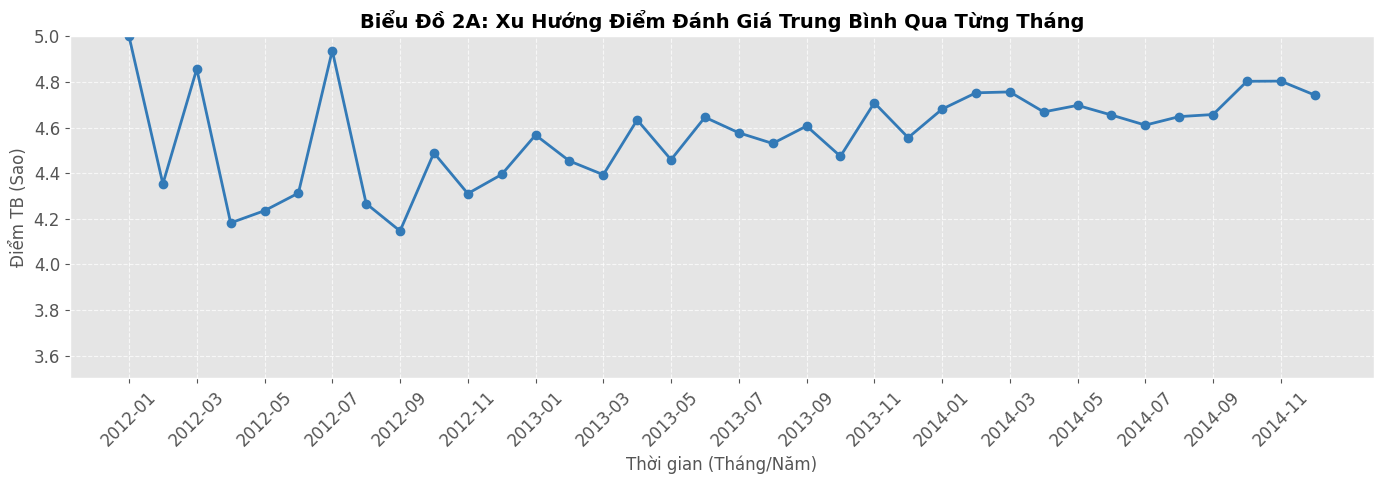

In [51]:
# Gom nhóm điểm trung bình theo tháng-năm
monthly_rating = df.groupby('YearMonth')['overall'].mean().reset_index()
monthly_rating['YearMonth_Str'] = monthly_rating['YearMonth'].astype(str)

# Biểu đồ 2A: Điểm đánh giá trung bình theo thời gian (Tháng/Năm)
plt.figure(figsize=(14, 5))
plt.plot(monthly_rating['YearMonth_Str'], monthly_rating['overall'], marker='o', color='#337ab7', linewidth=2)
plt.title('Biểu Đồ 2A: Xu Hướng Điểm Đánh Giá Trung Bình Qua Từng Tháng', fontsize=14, fontweight='bold')
plt.ylabel('Điểm TB (Sao)', fontsize=12)
plt.xlabel('Thời gian (Tháng/Năm)', fontsize=12)
plt.ylim(3.5, 5.0)
plt.xticks(rotation=45)

# Để trục X không quá rối, chọn hiển thị định kỳ
ax = plt.gca()
ticks = ax.get_xticks()
if len(ticks) > 15:
    ax.set_xticks(ticks[::len(ticks)//15])

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Nhận xét:** Điểm trải nghiệm thường khá dao động ban đầu nhưng dần đi vào ổn định theo thời gian.

#### Câu hỏi phụ 2B: Tổng số lượt bình chọn hữu ích qua thời gian thế nào?

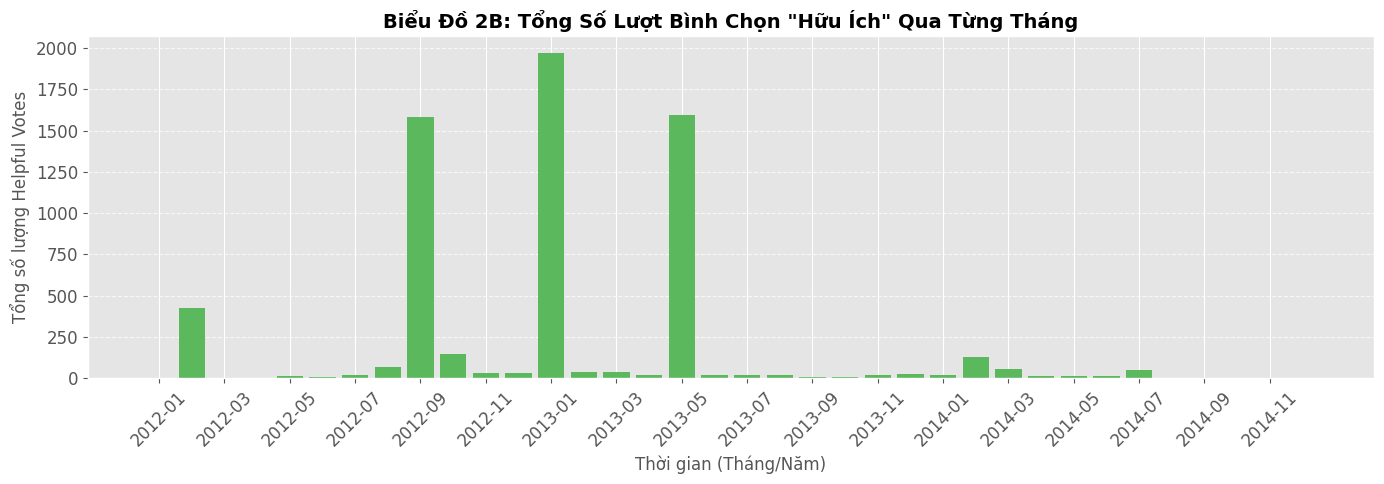

In [52]:
# Gom nhóm tổng số lượng vote hữu ích (helpful_yes) theo tháng-năm
monthly_helpful = df.groupby('YearMonth')['helpful_yes'].sum().reset_index()
monthly_helpful['YearMonth_Str'] = monthly_helpful['YearMonth'].astype(str)

# Biểu đồ 2B: Tương tác / Phản hồi hữu ích theo thời gian
plt.figure(figsize=(14, 5))
plt.bar(monthly_helpful['YearMonth_Str'], monthly_helpful['helpful_yes'], color='#5cb85c')
plt.title('Biểu Đồ 2B: Tổng Số Lượt Bình Chọn "Hữu Ích" Qua Từng Tháng', fontsize=14, fontweight='bold')
plt.xlabel('Thời gian (Tháng/Năm)', fontsize=12)
plt.ylabel('Tổng số lượng Helpful Votes', fontsize=12)
plt.xticks(rotation=45)

ax2 = plt.gca()
ticks2 = ax2.get_xticks()
if len(ticks2) > 15:
    ax2.set_xticks(ticks2[::len(ticks2)//15])

plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**Nhận xét:** Các bài đánh giá nhận được nhiều vote hữu ích nhất thường tập trung vào giai đoạn lúc sản phẩm mới ra mắt hoặc dịp khuyến mãi mua sắm đặc biệt.

#### Câu hỏi phụ 3: Những chủ đề chính (tích cực và tiêu cực) thường xuyên được đề cập là gì?

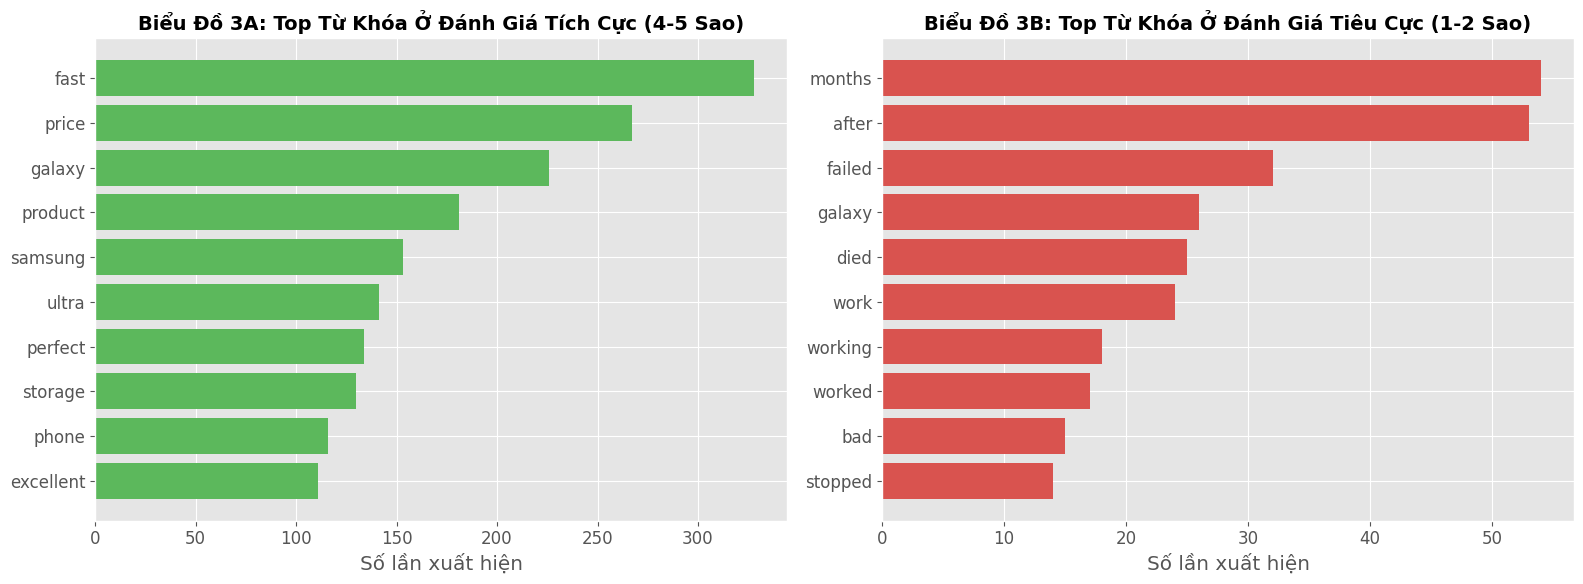

In [53]:
# Bước 1: Tách tập dữ liệu thành Positive (4-5 sao) và Negative (1-2 sao)
df_pos = df[df['overall'] >= 4]
df_neg = df[df['overall'] <= 2]

# Định nghĩa danh sách các từ dừng (stopwords) cơ bản tiếng Anh
stopwords = {'the', 'and', 'to', 'a', 'of', 'i', 'it', 'for', 'is', 'this', 'in', 'on', 'my', 'that', 'with', 'but',
            'was', 'as', 'card', 'sd', 'sandisk', 'micro', 'so', 'have', 'not', 'you', 'are', 'just', 'be', 'it\'s',
            'from', 'all', 'has', 'very', 'at', 'an', 'they', 'can', 'one', 'would', 'if', 'about', 'out', 'up',
            'what', 'when', 'them', 'get', 'like', 'than', 'me', 'had', 'no', 'do', 'will', 'card.', 'memory',
            'works', 'great', 'good'}

def get_top_words(text_series, top_n=10):
    words = re.findall(r'\b[a-z]{3,}\b', " ".join(text_series))
    filtered_words = [w for w in words if w not in stopwords]
    return Counter(filtered_words).most_common(top_n)

# Trích xuất top 10 từ xuất hiện ở tích cực và tiêu cực qua cột 'summary' (Tiêu đề tóm tắt)
top_pos_words = get_top_words(df_pos['summary'], 10)
top_neg_words = get_top_words(df_neg['summary'], 10)

# Chuyển đổi thành DataFrame
df_pos_words = pd.DataFrame(top_pos_words, columns=['Word', 'Count'])
df_neg_words = pd.DataFrame(top_neg_words, columns=['Word', 'Count'])

# Vẽ biểu đồ thanh ngang
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Đảo ngược thứ tự để từ có tần suất cao xuất hiện ở trên
df_pos_words = df_pos_words.iloc[::-1]
df_neg_words = df_neg_words.iloc[::-1]

# Biểu đồ Tích cực
axes[0].barh(df_pos_words['Word'], df_pos_words['Count'], color='#5cb85c')
axes[0].set_title('Biểu Đồ 3A: Top Từ Khóa Ở Đánh Giá Tích Cực (4-5 Sao)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Số lần xuất hiện')

# Biểu đồ Tiêu cực
axes[1].barh(df_neg_words['Word'], df_neg_words['Count'], color='#d9534f')
axes[1].set_title('Biểu Đồ 3B: Top Từ Khóa Ở Đánh Giá Tiêu Cực (1-2 Sao)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Số lần xuất hiện')

plt.tight_layout()
plt.show()

**Nhận xét:** Khách hàng hài lòng chủ yếu nói về sản phẩm "nhanh" (fast), "tuyệt vời" (excellent/perfect), "giá tốt" (price). Khách hàng không hài lòng thường đề cập cụm từ "chết" (died, dead), "hỏng" (failed, corrupt), hoặc "giả" (fake).

#### Câu hỏi phụ 4: Các vấn đề về "dung lượng thực tế", "tốc độ ghi" hoặc "độ bền" được thể hiện thế nào?

C:\Users\Lloyd2103\AppData\Local\Temp\ipykernel_16500\4033426819.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  aspect_counts = pd.DataFrame(columns=['1 Sao', '2 Sao', '3 Sao', '4 Sao', '5 Sao'], index=keywords.keys()).fillna(0)


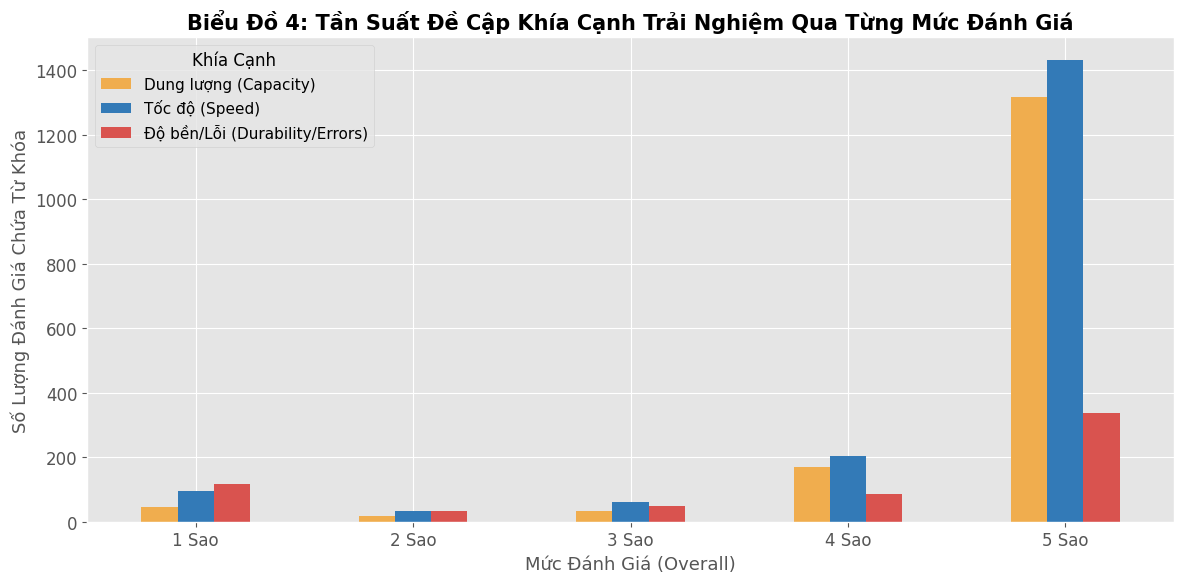

In [54]:
# Tạo các từ khóa đặc trưng cho ba khía cạnh
keywords = {
    'Dung lượng (Capacity)': ['space', 'gb', 'capacity', 'storage', 'full', 'size'],
    'Tốc độ (Speed)': ['fast', 'speed', 'slow', 'class 10', 'transfer', 'read', 'write'],
    'Độ bền/Lỗi (Durability/Errors)': ['died', 'dead', 'corrupt', 'failed', 'broken', 'issue', 'problem', 'stop']
}

# Mảng lưu kết quả tần suất xuất hiện theo từng khía cạnh qua từng mức đánh giá
aspect_counts = pd.DataFrame(columns=['1 Sao', '2 Sao', '3 Sao', '4 Sao', '5 Sao'], index=keywords.keys()).fillna(0)

for aspect, words in keywords.items():
    # Xây dựng regex tìm từ khóa
    pattern = '|'.join([fr"\b{w}\b" for w in words])
    for rating in range(1, 6):
        # Lọc các dòng có chứa từ khóa của khía cạnh đó ở cột reviewText
        mask_rating = df['overall'] == rating
        mask_text = df['reviewText'].str.contains(pattern, regex=True)
        count = df[mask_rating & mask_text].shape[0]
        aspect_counts.loc[aspect, f'{rating} Sao'] = count

# Chuyển đổi DataFrame sang format phù hợp cho Bar Chart
aspect_counts.T.plot(kind='bar', figsize=(12, 6), color=['#f0ad4e', '#337ab7', '#d9534f'])

plt.title('Biểu Đồ 4: Tần Suất Đề Cập Khía Cạnh Trải Nghiệm Qua Từng Mức Đánh Giá', fontsize=15, fontweight='bold')
plt.xlabel('Mức Đánh Giá (Overall)', fontsize=13)
plt.ylabel('Số Lượng Đánh Giá Chứa Từ Khóa', fontsize=13)
plt.xticks(rotation=0)
plt.legend(title='Khía Cạnh', fontsize=11)

plt.tight_layout()
plt.show()

**Nhận xét:**
- Ở nhóm 5 sao, "Dung lượng" và "Tốc độ" được người dùng đề cập cực kỳ nhiều với sắc thái hài lòng.
- Ở nhóm 1-2 sao, chủ đề "Độ bền/Lỗi" tăng vọt so với các chủ đề khác, cho thấy thẻ nhớ bị hỏng ngang là nguyên nhân chính khiến người dùng đánh giá thấp.

---

### 4. Kết Luận Chung (Conclusions)

1. **Tổng Quan Sự Hài Lòng:** SanDisk Ultra MicroSD nhận được phản hồi rất ấn tượng khi phần lớn người tiêu dùng đều xếp hạng 5 sao cho sản phẩm. Mức đánh giá trung bình cực kỳ cao cho thấy chất lượng sản phẩm đáp ứng hoàn hảo các nhu cầu cơ bản.
2. **Xu Hướng Thời Gian:** Mặc dù điểm số dao động ở giai đoạn đầu, nhưng dần định hình ổn định về sau. Đặc biệt, người dùng có xu hướng thảo luận và nhấn "hữu ích" nhiều nhất cho các bài đánh giá cung cấp chi tiết kỹ thuật ngay sau khi thẻ bán ra diện rộng.
3. **Tích cực & Tiêu cực:**
    - **Điểm mạnh (Tích cực):** Việc cung cấp *chính xác dung lượng* (great storage/capacity), thẻ *làm việc nhanh* (fast tranfer/speed) và *ổn định* là chìa khóa đạt 5 sao.
    - **Điểm yếu (Tiêu cực):** "Chết" thẻ (died/fail) và mất dữ liệu/lỗi phân vùng, cũng như việc e ngại hàng giả (fake) là khía cạnh then chốt dẫn tới đánh giá cực xấu ở mức 1 sao.
4. **Lời khuyên:** Dữ liệu cho thấy để cải thiện trải nghiệm, nhà cung cấp nên tập trung vào việc xử lý các lô thẻ bị lỗi phần cứng (durability) chết đột ngột và mạnh tay quản lý các kênh phân phối bán hàng giả.

**Dữ liệu đánh giá hoàn toàn có thể giúp chúng ta nắm bắt được "tiếng nói khách hàng" một cách trực quan, cụ thể và đáng tin cậy.**